In [3]:
%run "01_Data Loading.ipynb"
%run "03_Feature Engineering.ipynb"

All imports successful
Train shape : (2666, 20)
Test  shape : (667, 20)

Column dtypes:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Missing values: 0
All imports successful
Train shape : (2666, 20)
Test  shape : (667, 20)

Column dtypes:
State                      object
Account length              int64
Area code                   int64
Internati

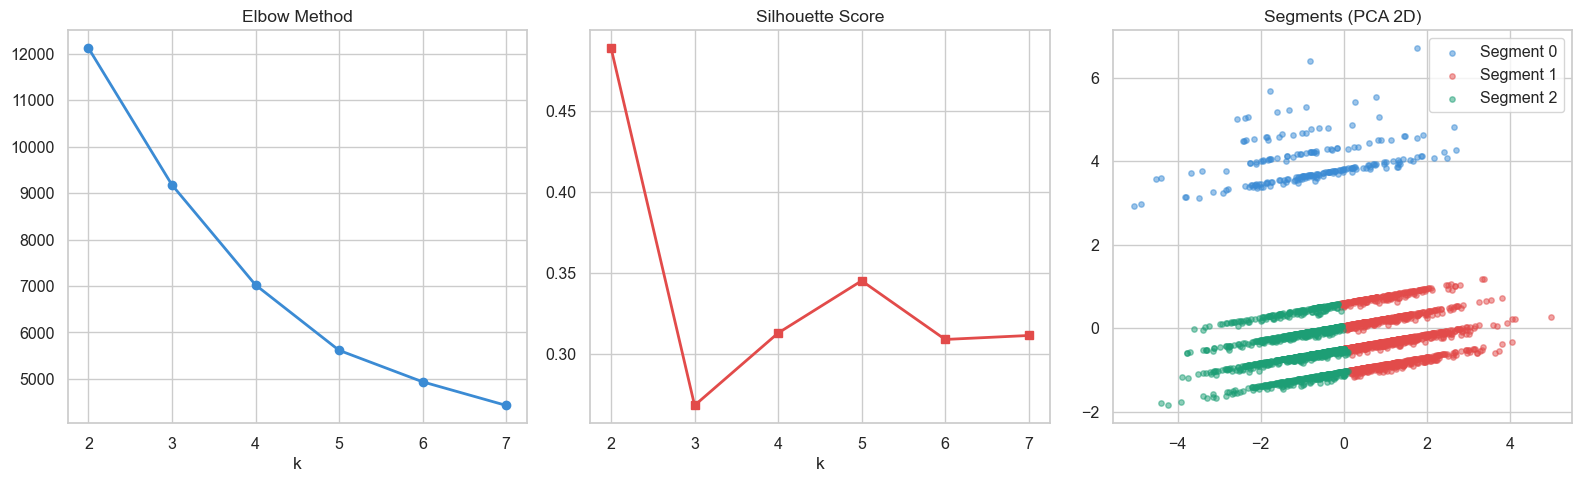


=== Segment Profiles ===
         Total minutes  Total charges  Customer service calls  \
Segment                                                         
0              587.287         58.807                   4.576   
1              658.619         67.237                   1.270   
2              519.395         50.975                   1.343   

         International plan  Number vmail messages  CS call flag  Churn  
Segment                                                                  
0                     0.105                  7.638           1.0  0.529  
1                     0.117                  8.294           0.0  0.170  
2                     0.084                  7.796           0.0  0.051  


In [5]:
seg_features = ['Total minutes','Total charges','Customer service calls',
                'International plan','Number vmail messages','CS call flag']
X_seg = StandardScaler().fit_transform(X_train[seg_features])


inertias, sils = [], []
for k in range(2, 8):
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_seg)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_seg, labs))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(range(2,8), inertias, 'o-', color='#3B8BD4', linewidth=2)
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k')
axes[1].plot(range(2,8), sils, 's-', color='#E24B4A', linewidth=2)
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')


km3         = KMeans(n_clusters=3, random_state=42, n_init=10)
seg_labels  = km3.fit_predict(X_seg)
X_pca       = PCA(n_components=2, random_state=42).fit_transform(X_seg)
for i, c in enumerate(['#3B8BD4','#E24B4A','#1D9E75']):
    m = seg_labels == i
    axes[2].scatter(X_pca[m,0], X_pca[m,1], c=c, alpha=0.5, s=15, label=f'Segment {i}')
axes[2].set_title('Segments (PCA 2D)'); axes[2].legend()
plt.tight_layout()
plt.show()

# Segment profiles
train_p['Segment'] = seg_labels
print("\n=== Segment Profiles ===")
print(train_p.groupby('Segment')[seg_features+['Churn']].mean().round(3))